<a href="https://colab.research.google.com/github/sisha1/checking/blob/main/faklcf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import zipfile
from google.colab import files

In [2]:
# --- 1. ZIP UPLOAD & EXTRACTION ---
print("Step 1: Upload your ZIP file.")
uploaded = files.upload()

extract_dir = '/content/extracted_csv_data'
if os.path.exists(extract_dir):
    import shutil
    shutil.rmtree(extract_dir)
os.makedirs(extract_dir)

for fn in uploaded.keys():
    if fn.endswith('.zip'):
        with zipfile.ZipFile(fn, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f"✅ Extracted to: {extract_dir}")

Step 1: Upload your ZIP file.


Saving sisha_os_sem2_dataset.zip to sisha_os_sem2_dataset.zip
✅ Extracted to: /content/extracted_csv_data


In [3]:
# --- 2. CLEANING & STRATIFIED SAMPLING ---
csv_files = glob.glob(os.path.join(extract_dir, "**/*.csv"), recursive=True)

if not csv_files:
    print("❌ No CSV files found. Please check the ZIP content.")
else:
    all_samples = []
    # We want ~1500 total rows. 1500 / 13 files ≈ 115 rows per file.
    samples_per_file = 1500 // len(csv_files)

    print(f"📊 Cleaning and sampling ~{samples_per_file} rows from each of the {len(csv_files)} files...")

    for f in csv_files:
        try:
            df = pd.read_csv(f)

            # Data Cleaning: Remove rows with missing critical values
            df = df.dropna(subset=['CPU usage [%]', 'Memory usage [KB]', 'Timestamp [ms]'])

            # Ensure numeric types
            df['CPU usage [%]'] = pd.to_numeric(df['CPU usage [%]'], errors='coerce')
            df['Memory usage [KB]'] = pd.to_numeric(df['Memory usage [KB]'], errors='coerce')
            df = df.dropna() # Drop rows that failed conversion

            # Random Sampling from THIS file
            if len(df) > samples_per_file:
                df_sample = df.sample(n=samples_per_file, random_state=42)
            else:
                df_sample = df # Take all if file is smaller than sample target

            df_sample['source_file'] = os.path.basename(f)
            all_samples.append(df_sample)
        except Exception as e:
            print(f"⚠️ Skipping {f} due to error: {e}")

    # Combine into well-structured DataFrame
    task_usage = pd.concat(all_samples, ignore_index=True)
    task_usage = task_usage.sort_values(by='Timestamp [ms]')
    print(f"✅ Well-structured DataFrame created with {len(task_usage)} rows.")

📊 Cleaning and sampling ~115 rows from each of the 13 files...
✅ Well-structured DataFrame created with 1495 rows.


migration
No Migration    1345
Migrate          150
Name: count, dtype: int64
                CI migration
650  122195.666719   Migrate
590   88081.179166   Migrate
633  116602.717123   Migrate
606  114368.268011   Migrate
867   86822.562845   Migrate
859  104018.767929   Migrate
901  109478.616201   Migrate
910  118279.754237   Migrate
813  108219.617628   Migrate
593   89202.107034   Migrate


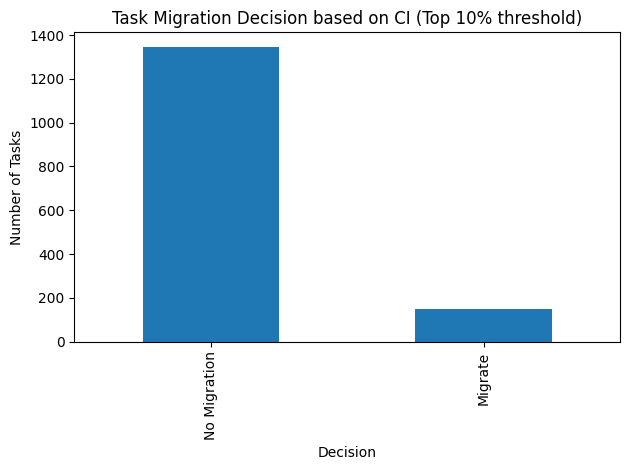

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 3. FEATURE ENGINEERING ---
np.random.seed(42)

task_usage['queue_length'] = np.random.randint(1, 21, len(task_usage))
task_usage['lock_contention'] = np.random.uniform(0, 1, len(task_usage))

# Formula
task_usage['CI'] = (
    0.4 * task_usage['CPU usage [%]'] +
    0.3 * (task_usage['queue_length'] / 20) +
    0.2 * task_usage['Memory usage [KB]'] +
    0.1 * task_usage['lock_contention']
)

def classify_load(ci):
    if ci < 30000: return "LOW"
    elif ci < 40000: return "MEDIUM"
    else: return "HIGH"

task_usage['load_level'] = task_usage['CI'].apply(classify_load)

task_usage['scheduler'] = task_usage['load_level'].map({
    "LOW": "Round Robin",
    "MEDIUM": "MLFQ",
    "HIGH": "SRTF"
})

task_usage['migration'] = task_usage['CI'].apply(
    lambda x: "Migrate" if x > task_usage['CI'].quantile(0.9) else "No Migration"
)

# 1. Count
print(task_usage['migration'].value_counts())

# 2. Show top migration rows
print(task_usage[task_usage['migration'] == "Migrate"][['CI', 'migration']].head(10))

# 3. Plot
task_usage['migration'].value_counts().plot(kind='bar')
plt.title("Task Migration Decision based on CI (Top 10% threshold)")
plt.xlabel("Decision")
plt.ylabel("Number of Tasks")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3519/2863808151.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 0], x='load_level', y='Memory usage [KB]', data=task_usage, order=['LOW', 'MEDIUM', 'HIGH'], palette='Set2')


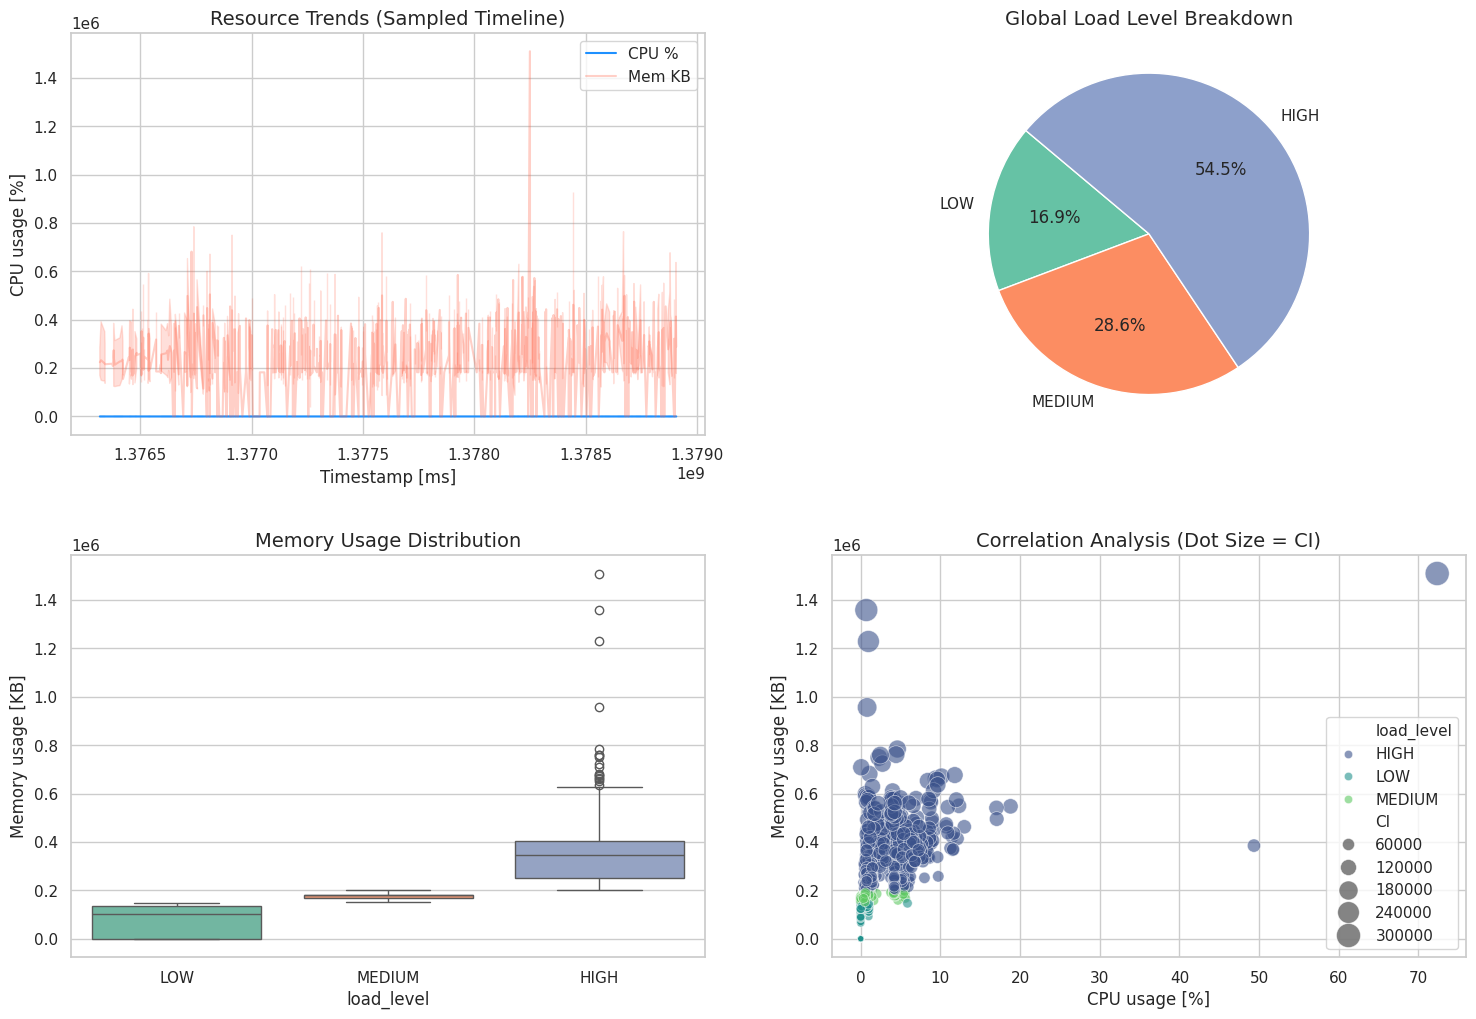

In [5]:
# --- 4. STRUCTURED DASHBOARD ---
sns.set(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.3)

# 1. Timeline (Now much faster due to sampling)
sns.lineplot(ax=axes[0, 0], x='Timestamp [ms]', y='CPU usage [%]', data=task_usage, color='dodgerblue', label='CPU %')
sns.lineplot(ax=axes[0, 0], x='Timestamp [ms]', y='Memory usage [KB]', data=task_usage, color='tomato', alpha=0.3, label='Mem KB')
axes[0, 0].set_title('Resource Trends (Sampled Timeline)', fontsize=14)
axes[0, 0].legend()

# 2. Distribution Pie Chart
load_counts = task_usage['load_level'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH'])
axes[0, 1].pie(load_counts, labels=load_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66c2a5','#fc8d62','#8da0cb'])
axes[0, 1].set_title('Global Load Level Breakdown', fontsize=14)

# 3. Memory Boxplot (Visualizing Stress)
sns.boxplot(ax=axes[1, 0], x='load_level', y='Memory usage [KB]', data=task_usage, order=['LOW', 'MEDIUM', 'HIGH'], palette='Set2')
axes[1, 0].set_title('Memory Usage Distribution', fontsize=14)

# 4. CPU vs Memory Scatter (Point size is Contention Index)
# Sampling makes this specific graph render instantly
sns.scatterplot(ax=axes[1, 1], x='CPU usage [%]', y='Memory usage [KB]', hue='load_level', size='CI',
                sizes=(20, 300), alpha=0.6, data=task_usage, palette='viridis')
axes[1, 1].set_title('Correlation Analysis (Dot Size = CI)', fontsize=14)

plt.show()

In [6]:
# --- 5. CLEAN OUTPUT SUMMARY ---
print("\n" + "="*50)
print("PROCESSED DATASET SUMMARY")
print("="*50)
print(f"Sample Size: {len(task_usage)} rows (Representing all 13 files)")
print("\nAverage Metrics per Load Group:")
display(task_usage.groupby('load_level')[['CPU usage [%]', 'Memory usage [KB]', 'CI']].mean())


PROCESSED DATASET SUMMARY
Sample Size: 1495 rows (Representing all 13 files)

Average Metrics per Load Group:


,CPU usage [%],Memory usage [KB],CI
load_level,,,
HIGH,3.496591,351469.448227,70295.492094
LOW,0.234392,72491.253741,14498.549696
MEDIUM,0.933011,176241.067112,35248.788750
